In [ ]:
# Cell 1 – Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"]   = "#f8f9fa"
plt.rcParams["axes.grid"]        = True
plt.rcParams["grid.alpha"]       = 0.3

CELL_COL = "CO_DN"

def short_cell_name(co_dn):
    """
    Input : PLMN-PLMN/MRBTS-803406/LNBTS-803406/LNCEL-41
    Output: LNBTS-803406_LNCEL-41
    """
    parts = str(co_dn).split("/")
    if len(parts) >= 2:
        return f"{parts[-2]}_{parts[-1]}"
    return str(co_dn)

# KPI thresholds — Vi network SLA
KPI_CONFIG = [
    {
        "col"      : "ERAB Drop Rate_Radio_Nokia_VeMr",
        "label"    : "Drop Rate",
        "threshold": 0.5,
        "direction": "high",   # bad when HIGH
        "weight"   : 30,
        "unit"     : "%",
    },
    {
        "col"      : "E2E Call Setup Success Rate_Nokia_VeMr",
        "label"    : "E2E CSSR",
        "threshold": 99.5,
        "direction": "low",    # bad when LOW
        "weight"   : 25,
        "unit"     : "%",
    },
    {
        "col"      : "VoLTE Call Setup Success Rate_Nokia_VeMr",
        "label"    : "VoLTE CSSR",
        "threshold": 99.5,
        "direction": "low",
        "weight"   : 20,
        "unit"     : "%",
    },
    {
        "col"      : "Average CQI_Nokia_VeMr",
        "label"    : "CQI",
        "threshold": 7.0,
        "direction": "low",
        "weight"   : 15,
        "unit"     : "",
    },
    {
        "col"      : "Nokia_LTE_DL_User_Throughput_Mbps",
        "label"    : "Avg Thpr",
        "threshold": 3.0,
        "direction": "low",
        "weight"   : 10,
        "unit"     : "Mbps",
    },
]

KPI_COLS = [k["col"] for k in KPI_CONFIG]
print("✅ Imports done")

✅ Imports done


In [2]:
# Cell 2 – Load data
import pyxlsb

CSV_PATH     = "../data/cleaned_master_data.csv"
RAW_FILE     = "../data/4G raw KPI Cell wise17th_June'26.xlsb"
ANOMALY_PATH = "../outputs/cell_anomaly_results.csv"
DAILY_PATH   = "../outputs/daily_outlier_events.csv"

# Master data
df = pd.read_csv(CSV_PATH)
if "Short_Cell" not in df.columns:
    df["Short_Cell"] = df[CELL_COL].apply(short_cell_name)

# Anomaly results from notebook 04
anomaly_df = pd.read_csv(ANOMALY_PATH)
daily_df   = pd.read_csv(DAILY_PATH)

# Convert KPIs to numeric
for col in KPI_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Sheet names for day ordering
with pyxlsb.open_workbook(RAW_FILE) as wb:
    sheet_names = wb.sheets

print(f"Master data shape  : {df.shape}")
print(f"Unique cells       : {df['Short_Cell'].nunique()}")
print(f"Anomaly results    : {anomaly_df.shape}")
print(f"Daily outliers     : {daily_df.shape}")

Master data shape  : (842125, 97)
Unique cells       : 51359
Anomaly results    : (51359, 10)
Daily outliers     : (42112, 10)


In [3]:
# Cell 3 – Root cause labelling functions

def safe_float(value):
    """Safely convert any value to float."""
    if value is None:
        return np.nan
    try:
        f = float(value)
        return np.nan if np.isinf(f) else f
    except (ValueError, TypeError):
        return np.nan


def get_root_cause(row):
    """
    Returns comma-separated string of violated KPI conditions.
    Uses exact column names and Vi network thresholds.
    """
    causes = []
    for cfg in KPI_CONFIG:
        col = cfg["col"]
        if col not in row.index:
            continue
        val = safe_float(row[col])
        if np.isnan(val):
            continue
        if cfg["direction"] == "high" and val > cfg["threshold"]:
            causes.append(
                f"High {cfg['label']} ({val:.2f}{cfg['unit']})"
            )
        if cfg["direction"] == "low" and val < cfg["threshold"]:
            causes.append(
                f"Low {cfg['label']} ({val:.2f}{cfg['unit']})"
            )
    return ", ".join(causes) if causes else "Anomaly (score-based)"


def count_fails(row):
    """Count how many KPI thresholds are breached."""
    count = 0
    for cfg in KPI_CONFIG:
        col = cfg["col"]
        if col not in row.index:
            continue
        val = safe_float(row[col])
        if np.isnan(val):
            continue
        if cfg["direction"] == "high" and val > cfg["threshold"]:
            count += 1
        if cfg["direction"] == "low"  and val < cfg["threshold"]:
            count += 1
    return count


def get_severity(fail_count):
    """Convert fail count to severity label."""
    if fail_count >= 4: return "Critical",  "🔴"
    if fail_count >= 3: return "High",      "🟠"
    if fail_count >= 2: return "Medium",    "🟡"
    if fail_count >= 1: return "Low",       "🟢"
    return                     "None",      "⚪"


print("✅ Root cause functions defined")
print(f"   Tracking {len(KPI_CONFIG)} KPIs")
print(f"   Thresholds:")
for cfg in KPI_CONFIG:
    direction = ">" if cfg["direction"] == "high" else "<"
    print(f"     {cfg['label']:<15} {direction} {cfg['threshold']}{cfg['unit']}")

✅ Root cause functions defined
   Tracking 5 KPIs
   Thresholds:
     Drop Rate       > 0.5%
     E2E CSSR        < 99.0%
     VoLTE CSSR      < 99.0%
     CQI             < 7.0
     Avg Thpr        < 3.0Mbps


In [4]:
# Cell 4 – Apply root cause labelling to entire dataset
# Vectorized — no iterrows()

kpi_present = [c for c in KPI_COLS if c in df.columns]

# ── Step 1: Vectorized breach flags per KPI ──
print("Computing breach flags...")
breach_flags = {}
for cfg in KPI_CONFIG:
    col = cfg["col"]
    if col not in df.columns:
        continue
    numeric = pd.to_numeric(df[col], errors="coerce")
    if cfg["direction"] == "high":
        breach_flags[cfg["label"]] = numeric > cfg["threshold"]
    else:
        breach_flags[cfg["label"]] = numeric < cfg["threshold"]

breach_df = pd.DataFrame(breach_flags).fillna(False)

# ── Step 2: Fail count per row ──
print("Computing fail counts...")
df["fail_count"] = breach_df.sum(axis=1).astype(int)

# ── Step 3: Root cause string per row ──
print("Building root cause strings...")
def build_root_cause_vectorized(df_row_idx):
    """Build root cause for all rows at once using breach_df."""
    all_causes = []
    for idx in range(len(df)):
        causes = []
        for cfg in KPI_CONFIG:
            label = cfg["label"]
            if label not in breach_df.columns:
                continue
            if breach_df.iloc[idx][label]:
                col = cfg["col"]
                val = safe_float(df.iloc[idx].get(col, np.nan))
                if not np.isnan(val):
                    if cfg["direction"] == "high":
                        causes.append(
                            f"High {label} ({val:.2f}{cfg['unit']})"
                        )
                    else:
                        causes.append(
                            f"Low {label} ({val:.2f}{cfg['unit']})"
                        )
        all_causes.append(
            ", ".join(causes) if causes else "Anomaly (score-based)"
        )
    return all_causes

# Use vectorized string building
cause_parts = []
for cfg in KPI_CONFIG:
    col   = cfg["col"]
    label = cfg["label"]
    if col not in df.columns or label not in breach_df.columns:
        continue
    numeric = pd.to_numeric(df[col], errors="coerce").round(2)
    mask    = breach_df[label]
    if cfg["direction"] == "high":
        prefix = f"High {label} ("
    else:
        prefix = f"Low {label} ("
    # Build partial cause string only for breaching rows
    partial = mask.map(
        lambda b, num=numeric, p=prefix, u=cfg["unit"]: None
    )
    # Vectorized string construction
    series = pd.Series([""] * len(df), index=df.index)
    series[mask] = (
        prefix + numeric[mask].astype(str) + cfg["unit"] + ")"
    )
    cause_parts.append(series)

# Combine all cause parts row-wise
cause_matrix = pd.concat(cause_parts, axis=1)
cause_matrix.columns = [cfg["label"] for cfg in KPI_CONFIG
                         if cfg["col"] in df.columns]

def join_causes(row):
    parts = [v for v in row if v != ""]
    return ", ".join(parts) if parts else "Anomaly (score-based)"

df["Root_Cause"] = cause_matrix.apply(join_causes, axis=1)

# ── Step 4: Severity ──
df["Severity"] = df["fail_count"].apply(
    lambda x: get_severity(x)[0]
)
df["Severity_Icon"] = df["fail_count"].apply(
    lambda x: get_severity(x)[1]
)

print(f"\n✅ Root cause labelling complete")
print(f"   Total rows labelled: {len(df):,}")
print(f"\nSeverity breakdown:")
print(df["Severity"].value_counts().to_string())

Computing breach flags...
Computing fail counts...
Building root cause strings...

✅ Root cause labelling complete
   Total rows labelled: 842,125

Severity breakdown:
Severity
None        671958
Low         120964
Medium       34840
High         10904
Critical      3459


In [5]:
# Cell 5 – Aggregate root causes at cell level
# Most common root cause per cell across all days

print("Building cell-level root cause summary...")

# Per cell — most common root cause
def most_common_cause(series):
    """Find most frequent root cause label across days."""
    import re
    all_parts = []
    for rc in series:
        if rc == "Anomaly (score-based)":
            continue
        for part in rc.split(","):
            # Strip value in brackets — keep just the label
            label = re.sub(r'\s*\(.*?\)', '', part).strip()
            if label:
                all_parts.append(label)
    if not all_parts:
        return "Anomaly (score-based)"
    from collections import Counter
    return Counter(all_parts).most_common(1)[0][0]

cell_rc = df.groupby("Short_Cell").agg(
    Days_Monitored    = ("Day",        "count"),
    Avg_Fail_Count    = ("fail_count", "mean"),
    Max_Fail_Count    = ("fail_count", "max"),
    Days_Any_Fail     = ("fail_count", lambda x: (x > 0).sum()),
    Top_Root_Cause    = ("Root_Cause", most_common_cause),
    Dominant_Severity = ("Severity",   lambda x:
                         x[x != "None"].mode()[0]
                         if len(x[x != "None"]) > 0 else "None"),
).reset_index()

# Add per-KPI breach day counts
for cfg in KPI_CONFIG:
    col   = cfg["col"]
    label = cfg["label"]
    if col not in df.columns:
        continue
    numeric = pd.to_numeric(df[col], errors="coerce")
    if cfg["direction"] == "high":
        mask = numeric > cfg["threshold"]
    else:
        mask = numeric < cfg["threshold"]
    mask = mask.fillna(False).astype(int)
    breach_counts = df.assign(_b=mask).groupby("Short_Cell")["_b"].sum()
    cell_rc[f"{label}_breach_days"] = (
        cell_rc["Short_Cell"].map(breach_counts).fillna(0).astype(int)
    )

cell_rc["Persistence_%"] = (
    cell_rc["Days_Any_Fail"] / cell_rc["Days_Monitored"] * 100
).round(1)

cell_rc = cell_rc.sort_values(
    ["Max_Fail_Count", "Avg_Fail_Count"],
    ascending=[False, False]
).reset_index(drop=True)

print(f"✅ Cell-level root cause summary: {len(cell_rc)} cells")
print(f"\nTop 10 cells by severity:\n")
print(cell_rc[[
    "Short_Cell", "Max_Fail_Count",
    "Days_Any_Fail", "Persistence_%",
    "Top_Root_Cause"
]].head(10).to_string(index=False))

Building cell-level root cause summary...
✅ Cell-level root cause summary: 51359 cells

Top 10 cells by severity:

           Short_Cell  Max_Fail_Count  Days_Any_Fail  Persistence_% Top_Root_Cause
LNBTS-404895_LNCEL-93               5             17          100.0 High Drop Rate
LNBTS-804808_LNCEL-92               5             17          100.0 High Drop Rate
LNBTS-401481_LNCEL-92               5             17          100.0 High Drop Rate
LNBTS-405919_LNCEL-93               5             17          100.0 High Drop Rate
LNBTS-804603_LNCEL-92               5             17          100.0 High Drop Rate
LNBTS-803792_LNCEL-93               5             17          100.0 Low VoLTE CSSR
LNBTS-804268_LNCEL-92               5             17          100.0 High Drop Rate
LNBTS-804330_LNCEL-92               5             17          100.0 High Drop Rate
LNBTS-404895_LNCEL-41               5             17          100.0 High Drop Rate
LNBTS-801140_LNCEL-42               5             17   

Root Cause Frequency — Entire Network (All Days):

    Root Cause  Frequency
  Low E2E CSSR      67495
  Low Avg Thpr      60799
High Drop Rate      52045
Low VoLTE CSSR      35742
       Low CQI      21649


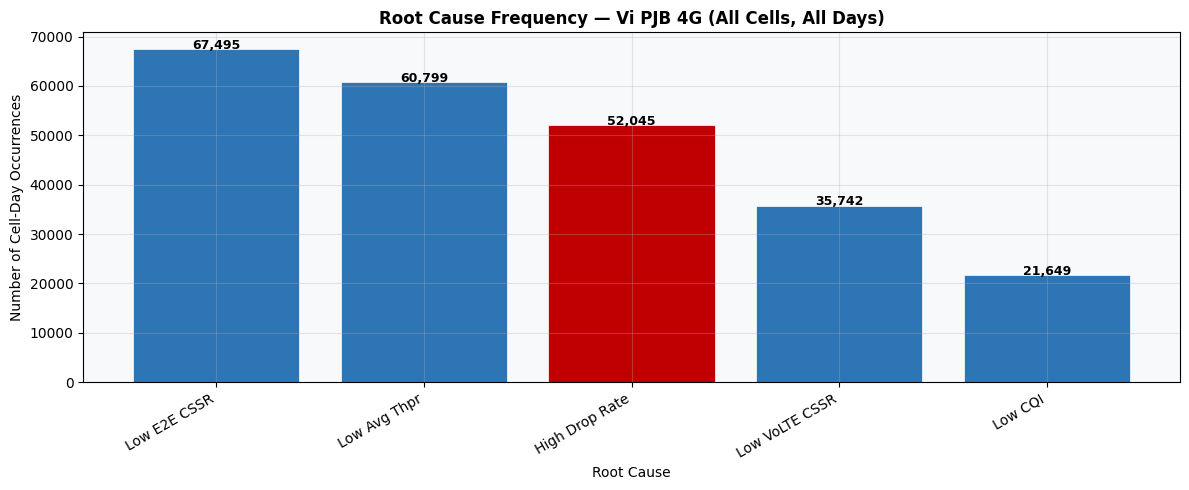

✅ Saved → outputs/rc_frequency.png


In [6]:
# Cell 6 – Which root causes appear most across the network?

import re
from collections import Counter

all_causes = []
for rc in df["Root_Cause"]:
    if rc == "Anomaly (score-based)":
        continue
    for part in rc.split(","):
        label = re.sub(r'\s*\(.*?\)', '', part).strip()
        if label:
            all_causes.append(label)

cause_counts = Counter(all_causes)
cause_df     = pd.DataFrame(
    cause_counts.items(),
    columns=["Root Cause", "Frequency"]
).sort_values("Frequency", ascending=False).reset_index(drop=True)

print("Root Cause Frequency — Entire Network (All Days):\n")
print(cause_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
colors  = ["#C00000" if "High" in rc or "Drop" in rc
           else "#2E75B6" for rc in cause_df["Root Cause"]]

bars = ax.bar(
    cause_df["Root Cause"],
    cause_df["Frequency"],
    color=colors, edgecolor="white", linewidth=0.5
)
for bar, val in zip(bars, cause_df["Frequency"]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 50,
            f"{val:,}", ha="center", fontsize=9, fontweight="bold")

ax.set_title("Root Cause Frequency — Vi PJB 4G (All Cells, All Days)",
             fontweight="bold", fontsize=12)
ax.set_xlabel("Root Cause")
ax.set_ylabel("Number of Cell-Day Occurrences")
ax.set_xticklabels(cause_df["Root Cause"], rotation=30, ha="right")
plt.tight_layout()
plt.savefig("../outputs/rc_frequency.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → outputs/rc_frequency.png")

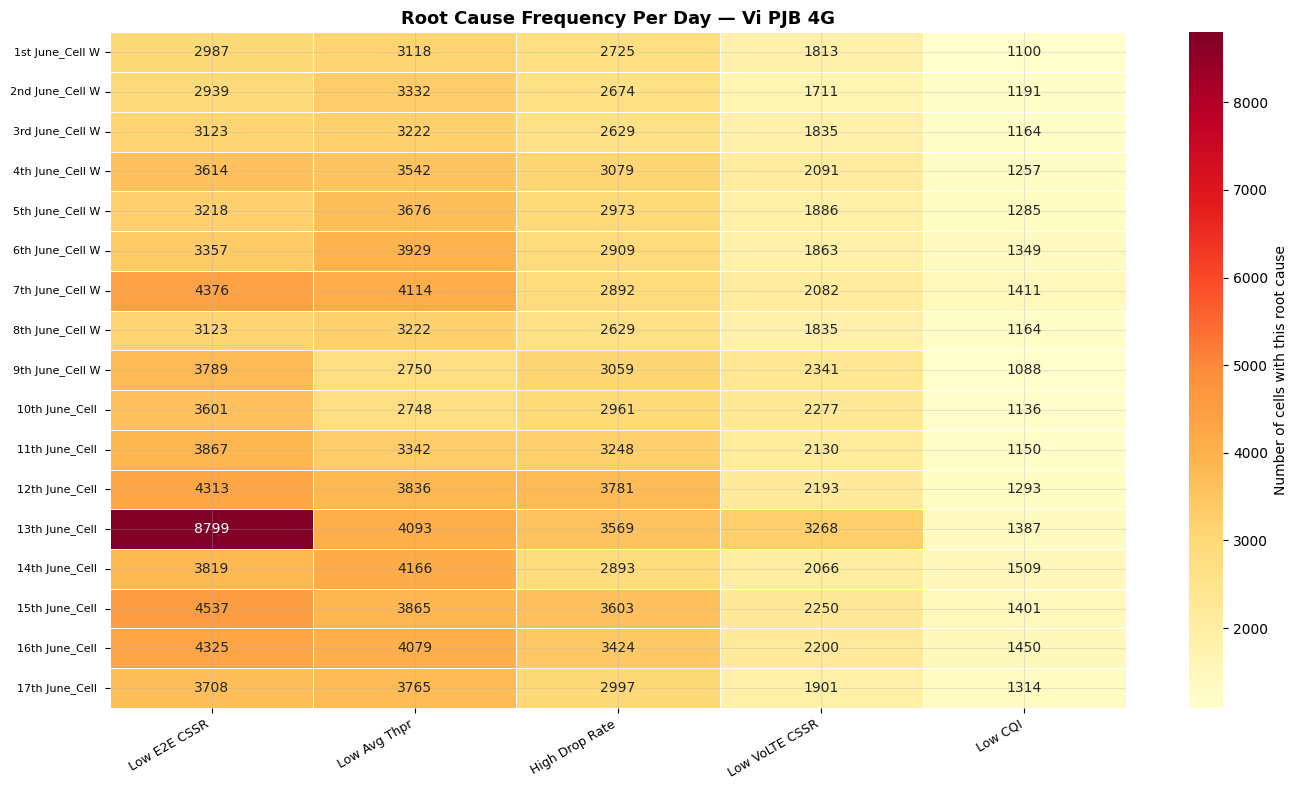

✅ Saved → outputs/rc_heatmap_by_day.png


In [7]:
# Cell 7 – How root cause frequency changes across 17 days

rc_by_day = {}
for day in sheet_names:
    day_df    = df[df["Day"] == day]["Root_Cause"]
    day_parts = []
    for rc in day_df:
        if rc == "Anomaly (score-based)":
            continue
        for part in rc.split(","):
            label = re.sub(r'\s*\(.*?\)', '', part).strip()
            if label:
                day_parts.append(label)
    rc_by_day[day] = Counter(day_parts)

all_labels = list(cause_df["Root Cause"])
heat_data  = pd.DataFrame(
    {day: [rc_by_day[day].get(lbl, 0) for lbl in all_labels]
     for day in sheet_names},
    index=all_labels
).T

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    heat_data,
    annot     = True,
    fmt       = "d",
    cmap      = "YlOrRd",
    linewidths= 0.5,
    ax        = ax,
    cbar_kws  = {"label": "Number of cells with this root cause"}
)
ax.set_title("Root Cause Frequency Per Day — Vi PJB 4G",
             fontweight="bold", fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(),
                   rotation=30, ha="right", fontsize=9)
ax.set_yticklabels(
    [s[:15] for s in sheet_names],
    rotation=0, fontsize=8
)
plt.tight_layout()
plt.savefig("../outputs/rc_heatmap_by_day.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → outputs/rc_heatmap_by_day.png")

In [8]:
# Cell 8 – Merge root cause with Isolation Forest anomaly scores

# Merge cell-level root cause with anomaly scores from nb04
merged = cell_rc.merge(
    anomaly_df[["Short_Cell", "anomaly_flag",
                "anomaly_score", "total_breach_days"]],
    on  = "Short_Cell",
    how = "left"
)

# Flag critical cells — anomaly + high persistence
merged["Priority"] = (
    (merged["anomaly_flag"] == -1) &
    (merged["Persistence_%"] >= 40)
)

critical = merged[merged["Priority"]].sort_values(
    ["Max_Fail_Count", "anomaly_score"],
    ascending=[False, True]
).reset_index(drop=True)

print(f"Critical cells (anomaly + ≥40% persistence): {len(critical)}")
print(f"\nTop 15 priority cells:\n")
print(critical[[
    "Short_Cell", "anomaly_score",
    "Max_Fail_Count", "Persistence_%",
    "Top_Root_Cause", "Dominant_Severity"
]].head(15).to_string(index=False))

Critical cells (anomaly + ≥40% persistence): 2315

Top 15 priority cells:

           Short_Cell  anomaly_score  Max_Fail_Count  Persistence_% Top_Root_Cause Dominant_Severity
LNBTS-806471_LNCEL-91      -0.756410               5          100.0 High Drop Rate          Critical
LNBTS-802012_LNCEL-93      -0.755023               5          100.0 High Drop Rate              High
LNBTS-402560_LNCEL-92      -0.753786               5          100.0 High Drop Rate          Critical
LNBTS-804808_LNCEL-92      -0.743183               5          100.0 High Drop Rate          Critical
LNBTS-401481_LNCEL-92      -0.738923               5          100.0 High Drop Rate          Critical
LNBTS-404895_LNCEL-93      -0.736499               5          100.0 High Drop Rate          Critical
LNBTS-405919_LNCEL-93      -0.731256               5          100.0 High Drop Rate          Critical
LNBTS-804268_LNCEL-92      -0.730197               5          100.0 High Drop Rate          Critical
LNBTS-401696_LNC

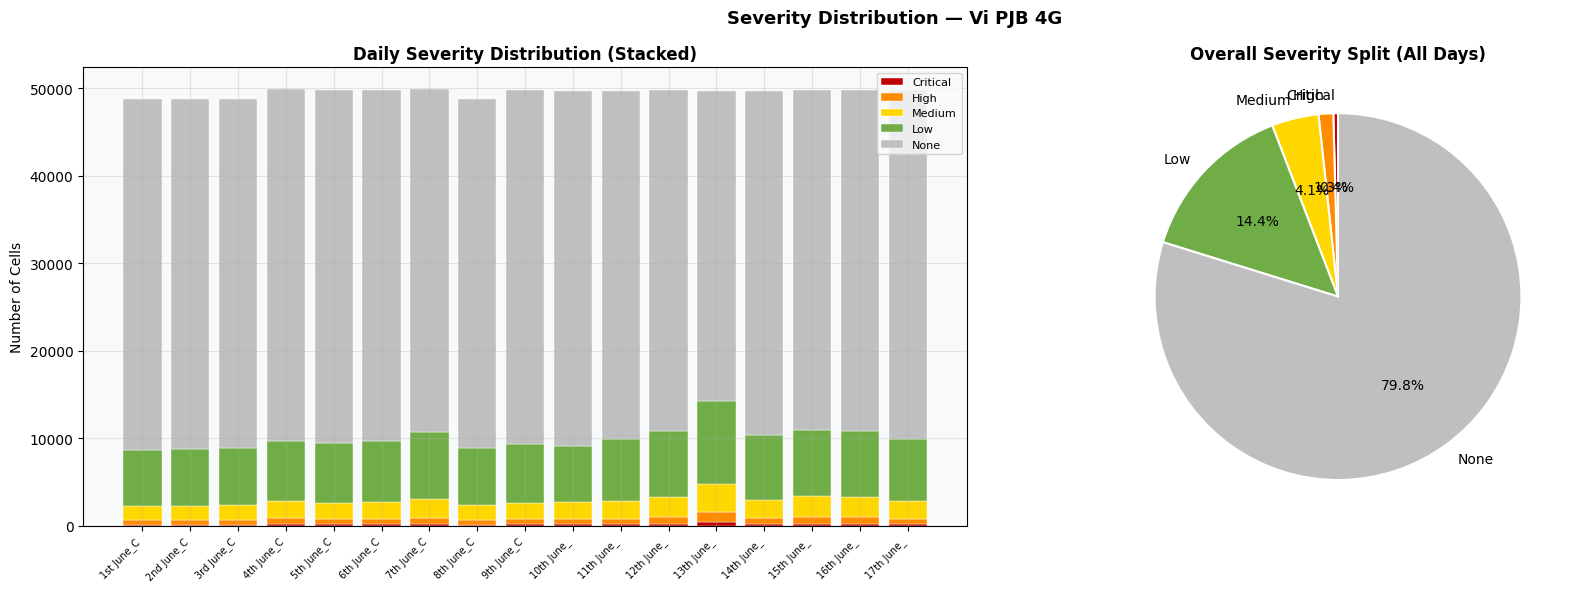

✅ Saved → outputs/rc_severity_distribution.png


In [9]:
# Cell 9 – Severity distribution per day

severity_order  = ["Critical", "High", "Medium", "Low", "None"]
severity_colors = {
    "Critical": "#C00000",
    "High"    : "#FF8C00",
    "Medium"  : "#FFD700",
    "Low"     : "#70AD47",
    "None"    : "#BFBFBF",
}

sev_by_day = pd.crosstab(df["Day"], df["Severity"])
sev_by_day = sev_by_day.reindex(
    index   = sheet_names,
    columns = severity_order,
    fill_value=0
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Severity Distribution — Vi PJB 4G",
             fontsize=13, fontweight="bold")

# Plot 1 — Stacked bar per day
bottom = np.zeros(len(sheet_names))
for sev in severity_order:
    if sev not in sev_by_day.columns:
        continue
    vals = sev_by_day[sev].values
    axes[0].bar(
        range(len(sheet_names)),
        vals,
        bottom=bottom,
        color=severity_colors[sev],
        label=sev, edgecolor="white", linewidth=0.3
    )
    bottom += vals

axes[0].set_xticks(range(len(sheet_names)))
axes[0].set_xticklabels(
    [s[:10] for s in sheet_names],
    rotation=45, ha="right", fontsize=7
)
axes[0].set_title("Daily Severity Distribution (Stacked)",
                  fontweight="bold")
axes[0].set_ylabel("Number of Cells")
axes[0].legend(fontsize=8, loc="upper right")

# Plot 2 — Overall severity pie
overall = df["Severity"].value_counts()
overall = overall.reindex(
    [s for s in severity_order if s in overall.index]
)
axes[1].pie(
    overall.values,
    labels    = overall.index,
    colors    = [severity_colors[s] for s in overall.index],
    autopct   = "%1.1f%%",
    startangle= 90,
    wedgeprops= dict(edgecolor="white", linewidth=1.5)
)
axes[1].set_title("Overall Severity Split (All Days)",
                  fontweight="bold")

plt.tight_layout()
plt.savefig("../outputs/rc_severity_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → outputs/rc_severity_distribution.png")

In [10]:
# Cell 10 – Save all root cause outputs

# 1. Full dataset with root cause labels
df[[
    CELL_COL, "Short_Cell", "Day",
    "fail_count", "Severity", "Root_Cause"
] + [c for c in KPI_COLS if c in df.columns]
].to_csv("../outputs/root_cause_labelled.csv", index=False)
print("✅ Saved → outputs/root_cause_labelled.csv")

# 2. Cell-level root cause summary
cell_rc.to_csv(
    "../outputs/cell_root_cause_summary.csv", index=False
)
print("✅ Saved → outputs/cell_root_cause_summary.csv")

# 3. Priority cells with root cause
critical[[
    "Short_Cell", "anomaly_score",
    "Max_Fail_Count", "Persistence_%",
    "Top_Root_Cause", "Dominant_Severity",
    "Days_Any_Fail", "Days_Monitored"
]].to_csv("../outputs/priority_cells_with_rc.csv", index=False)
print("✅ Saved → outputs/priority_cells_with_rc.csv")

# 4. Root cause frequency
cause_df.to_csv(
    "../outputs/root_cause_frequency.csv", index=False
)
print("✅ Saved → outputs/root_cause_frequency.csv")

print(f"\nAll files saved to outputs/")

✅ Saved → outputs/root_cause_labelled.csv
✅ Saved → outputs/cell_root_cause_summary.csv
✅ Saved → outputs/priority_cells_with_rc.csv
✅ Saved → outputs/root_cause_frequency.csv

All files saved to outputs/


In [11]:
# Cell 11 – Summary printout

print("=" * 60)
print("ROOT CAUSE ANALYSIS SUMMARY — Vi PJB 4G")
print("=" * 60)
print(f"\nData Coverage:")
print(f"  Days monitored    : {df['Day'].nunique()}")
print(f"  Unique cells      : {df['Short_Cell'].nunique()}")
print(f"  Total records     : {len(df):,}")

print(f"\nSeverity Breakdown (cell-day level):")
sev_counts = df["Severity"].value_counts()
total      = len(df)
for sev in severity_order:
    cnt = sev_counts.get(sev, 0)
    pct = cnt / total * 100
    bar = "█" * int(pct / 2)
    print(f"  {sev:<10} {cnt:>6,}  ({pct:>5.1f}%)  {bar}")

print(f"\nTop Root Causes:")
for i, row in cause_df.head(5).iterrows():
    print(f"  {i+1}. {row['Root Cause']:<25} "
          f"{row['Frequency']:>6,} occurrences")

print(f"\nPriority Cells (dispatch required): {len(critical)}")
print(f"\nOutput Files:")
for f in [
    "root_cause_labelled.csv",
    "cell_root_cause_summary.csv",
    "priority_cells_with_rc.csv",
    "root_cause_frequency.csv",
]:
    import os
    path   = f"../outputs/{f}"
    exists = "✅" if os.path.exists(path) else "❌"
    print(f"  {exists}  {f}")

ROOT CAUSE ANALYSIS SUMMARY — Vi PJB 4G

Data Coverage:
  Days monitored    : 17
  Unique cells      : 51359
  Total records     : 842,125

Severity Breakdown (cell-day level):
  Critical    3,459  (  0.4%)  
  High       10,904  (  1.3%)  
  Medium     34,840  (  4.1%)  ██
  Low        120,964  ( 14.4%)  ███████
  None       671,958  ( 79.8%)  ███████████████████████████████████████

Top Root Causes:
  1. Low E2E CSSR              67,495 occurrences
  2. Low Avg Thpr              60,799 occurrences
  3. High Drop Rate            52,045 occurrences
  4. Low VoLTE CSSR            35,742 occurrences
  5. Low CQI                   21,649 occurrences

Priority Cells (dispatch required): 2315

Output Files:
  ✅  root_cause_labelled.csv
  ✅  cell_root_cause_summary.csv
  ✅  priority_cells_with_rc.csv
  ✅  root_cause_frequency.csv
